### TP3 — Detección de logo por Template Matching
Integrantes:  
Julián Barceló  
Jonatan Mild  
Víctor Hugo Astorga  
Roberto Manuel Briend  
Valentín Torres  

### Consigna
Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en images/ a partir del template template/pattern.png.  

1- (4 pts) Obtener una detección del logo en cada imagen sin falsos positivos.  

2- (4 pts) Plantear y validar un algoritmo para múltiples detecciones en coca_multi.png con el mismo template del ítem 1.  

3- (2 pts) Generalizar el algoritmo del ítem 2 para todas las imágenes.
Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.

In [3]:
%matplotlib inline

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
template_file = "./template/pattern.png"
images_path = "./images/"
file_list = [
    'logo_1.png',
    'coca_logo_1.png',
    'coca_logo_2.png',
    'coca_multi.png',
    'coca_retro_1.png',
    'coca_retro_2.png',
    'COCA-COLA-LOGO.jpg'
]

template = cv.imread(template_file)

if template is None:
    raise FileNotFoundError("No se encontró pattern.png")

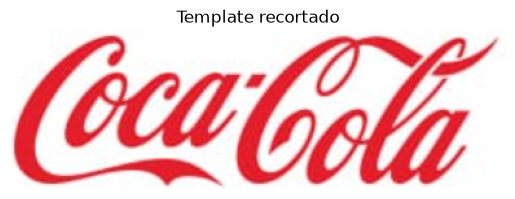

In [5]:
def crop_template(template, threshold=245):

    # Detectamos píxeles que no sean prácticamente blancos
    mask = np.any(template < threshold, axis=2)

    y, x = np.where(mask)

    template_crop = template[
        y.min():y.max()+1,
        x.min():x.max()+1
    ]

    return template_crop


template = crop_template(template)

plt.imshow(cv.cvtColor(template, cv.COLOR_BGR2RGB))
plt.title("Template recortado")
plt.axis("off")
plt.show()

In [6]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)


def get_edges(img, is_template=False):

    gray = to_gray(img)

    # Suavizado para reducir ruido
    gray = cv.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    # Bordes
    edges = cv.Canny(
        gray,
        50,
        150
    )

    # En las imágenes ensanchamos ligeramente los bordes
    # para tolerar pequeñas diferencias respecto del template.
    if not is_template:

        kernel = np.ones(
            (3, 3),
            dtype=np.uint8
        )

        edges = cv.dilate(
            edges,
            kernel,
            iterations=1
        )

    # Suavizamos levemente los bordes para hacer
    # el matching menos rígido
    edges = cv.GaussianBlur(
        edges,
        (0, 0),
        3
    )

    return edges

In [7]:
def matching_score(
    img_gray,
    img_edges,
    template_gray,
    template_edges,
    scale
):

    h_template, w_template = template_gray.shape

    w = int(round(w_template * scale))
    h = int(round(h_template * scale))

    # Si el template no entra en la imagen
    if (
        w < 55
        or h < 18
        or w > img_gray.shape[1]
        or h > img_gray.shape[0]
    ):
        return None

    template_gray_scaled = cv.resize(
        template_gray,
        (w, h)
    )

    template_edges_scaled = cv.resize(
        template_edges,
        (w, h)
    )

    # Matching por intensidad
    response_gray = cv.matchTemplate(
        img_gray,
        template_gray_scaled,
        cv.TM_CCOEFF_NORMED
    )

    # Matching por bordes
    response_edges = cv.matchTemplate(
        img_edges,
        template_edges_scaled,
        cv.TM_CCORR_NORMED
    )

    # Combinamos ambos resultados.
    # Damos mayor importancia a los bordes.
    score = (
        0.7 * response_edges
        +
        0.3 * np.abs(response_gray)
    )

    return score, w, h

In [8]:
scales = np.linspace(
    0.15,
    3.2,
    45
)

In [9]:
def evaluate_scales(img, template, scales):

    img_gray = to_gray(img)
    img_edges = get_edges(img)

    template_gray = to_gray(template)
    template_edges = get_edges(
        template,
        is_template=True
    )

    results = []

    for scale in scales:

        result = matching_score(
            img_gray,
            img_edges,
            template_gray,
            template_edges,
            scale
        )

        if result is None:
            continue

        score_map, w, h = result

        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(
            score_map
        )

        results.append({
            "scale": scale,
            "score_map": score_map,
            "max_score": max_val,
            "max_loc": max_loc,
            "w": w,
            "h": h
        })

    return results

### 1 - Obtener una detección del logo en cada imagen, sin falsos positivos.

In [10]:
def detect_one(
    img,
    template,
    scales,
    delta=0.04
):

    results = evaluate_scales(
        img,
        template,
        scales
    )

    best_score = max(
        result["max_score"]
        for result in results
    )

    # Escalas cuyo resultado está muy cerca del mejor
    candidates = [
        result
        for result in results
        if result["max_score"] >= best_score - delta
    ]

    # Entre resultados casi equivalentes,
    # elegimos el template más grande
    best = max(
        candidates,
        key=lambda x: x["scale"]
    )

    x, y = best["max_loc"]

    detection = {
        "x1": x,
        "y1": y,
        "x2": x + best["w"],
        "y2": y + best["h"],
        "score": best["max_score"],
        "scale": best["scale"]
    }

    return detection

In [11]:
def draw_detection(img, detection):

    output = img.copy()

    x1 = detection["x1"]
    y1 = detection["y1"]
    x2 = detection["x2"]
    y2 = detection["y2"]

    score = detection["score"]

    cv.rectangle(
        output,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv.putText(
        output,
        f"{score:.2f}",
        (x1, max(15, y1 - 5)),
        cv.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv.LINE_AA
    )

    return output

logo_1.png score: 0.686 scale: 0.774


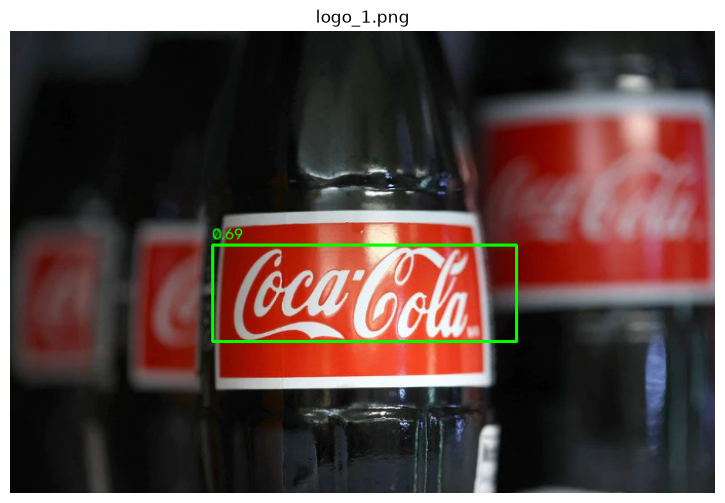

coca_logo_1.png score: 0.714 scale: 0.427


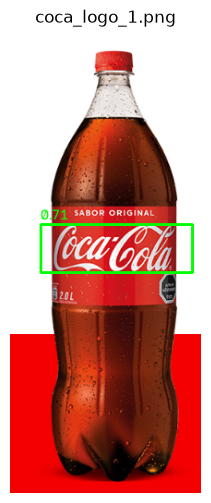

coca_logo_2.png score: 0.58 scale: 0.566


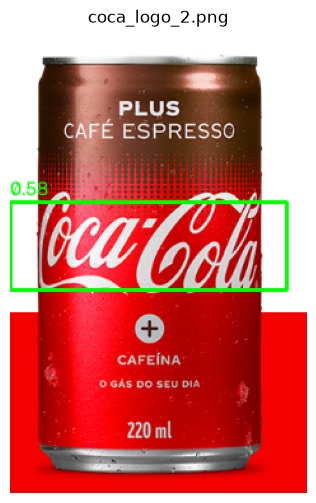

coca_multi.png score: 0.699 scale: 0.219


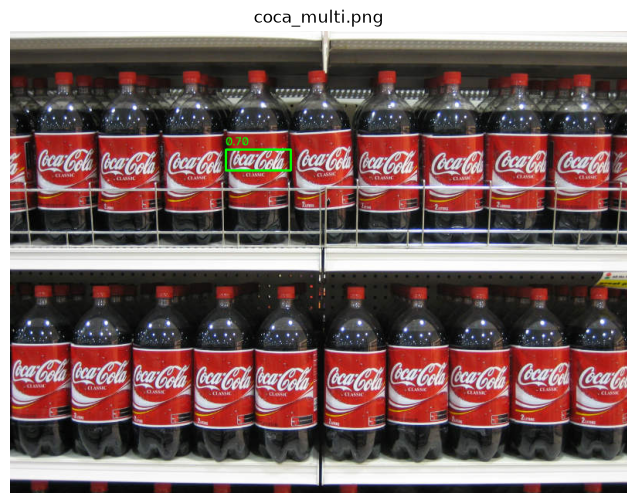

coca_retro_1.png score: 0.79 scale: 1.328


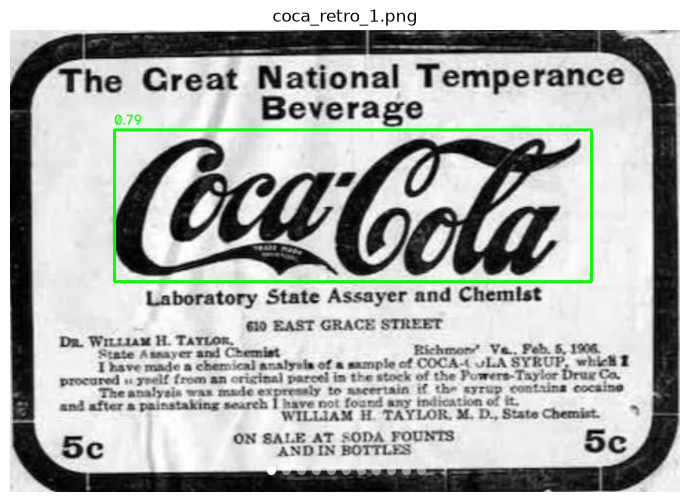

coca_retro_2.png score: 0.742 scale: 0.358


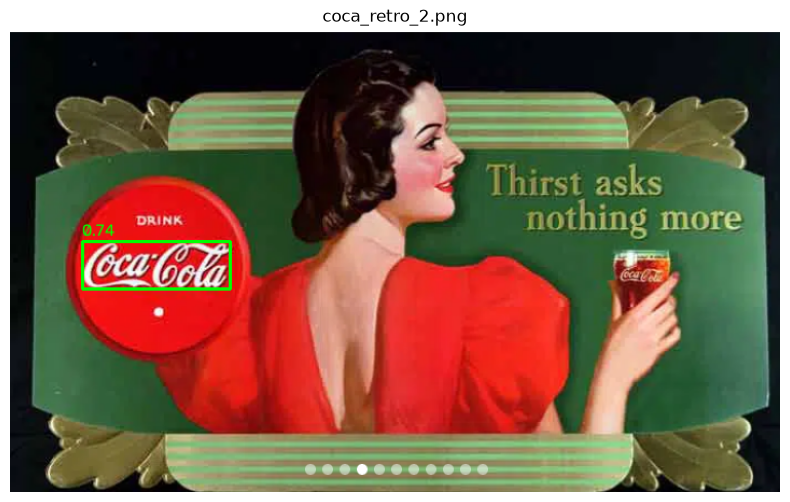

COCA-COLA-LOGO.jpg score: 0.61 scale: 3.2


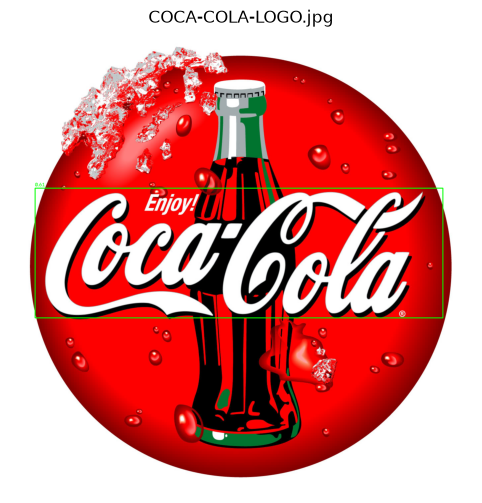

In [21]:
for image_name in file_list:
    image_path = "./images/"

    img = cv.imread(image_path + image_name)

    if img is None:
        print(f"No se encontró {image_path + image_name}")
        continue

    detection = detect_one(
        img,
        template,
        scales
    )

    output = draw_detection(
        img,
        detection
    )

    print(
        image_name,
        "score:",
        round(detection["score"], 3),
        "scale:",
        round(detection["scale"], 3)
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        cv.cvtColor(
            output,
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(image_name)
    plt.axis("off")
    plt.show()

### 2- Plantear y validar un algoritmo para múltiples detecciones en coca_multi.png con el mismo template del ítem 1

In [22]:
def nms(
    boxes,
    scores,
    iou_threshold=0.20
):

    if len(boxes) == 0:
        return []

    boxes = np.array(
        boxes,
        dtype=np.float32
    )

    scores = np.array(scores)

    order = scores.argsort()[::-1]

    keep = []

    while order.size > 0:

        i = order[0]

        keep.append(i)

        if order.size == 1:
            break

        x1 = np.maximum(
            boxes[i, 0],
            boxes[order[1:], 0]
        )

        y1 = np.maximum(
            boxes[i, 1],
            boxes[order[1:], 1]
        )

        x2 = np.minimum(
            boxes[i, 2],
            boxes[order[1:], 2]
        )

        y2 = np.minimum(
            boxes[i, 3],
            boxes[order[1:], 3]
        )

        intersection = (
            np.maximum(0, x2 - x1)
            *
            np.maximum(0, y2 - y1)
        )

        area_i = (
            (boxes[i, 2] - boxes[i, 0])
            *
            (boxes[i, 3] - boxes[i, 1])
        )

        areas = (
            (boxes[order[1:], 2] - boxes[order[1:], 0])
            *
            (boxes[order[1:], 3] - boxes[order[1:], 1])
        )

        iou = intersection / (
            area_i
            + areas
            - intersection
            + 1e-9
        )

        order = order[1:][
            iou < iou_threshold
        ]

    return keep

In [23]:
def get_detections(
    score_map,
    w,
    h,
    threshold=0.62,
    iou_threshold=0.20
):

    kernel = np.ones(
        (7, 7),
        dtype=np.uint8
    )

    local_max = cv.dilate(
        score_map,
        kernel
    )

    mask = (
        (score_map >= threshold)
        &
        (score_map >= local_max - 1e-7)
    )

    y_points, x_points = np.where(mask)

    boxes = []
    scores = []

    for x, y in zip(
        x_points,
        y_points
    ):

        boxes.append([
            x,
            y,
            x + w,
            y + h
        ])

        scores.append(
            float(score_map[y, x])
        )

    keep = nms(
        boxes,
        scores,
        iou_threshold
    )

    detections = []

    for i in keep:

        detections.append({
            "x1": int(boxes[i][0]),
            "y1": int(boxes[i][1]),
            "x2": int(boxes[i][2]),
            "y2": int(boxes[i][3]),
            "score": scores[i]
        })

    return detections

In [25]:
img = cv.imread(
    './images/coca_multi.png'
)

img_gray = to_gray(img)
img_edges = get_edges(img)

template_gray = to_gray(template)

template_edges = get_edges(
    template,
    is_template=True
)

scale = 0.226

result = matching_score(
    img_gray,
    img_edges,
    template_gray,
    template_edges,
    scale
)

score_map, w, h = result

detections = get_detections(
    score_map,
    w,
    h,
    threshold=0.62,
    iou_threshold=0.20
)

print(
    "Cantidad de detecciones:",
    len(detections)
)

Cantidad de detecciones: 17


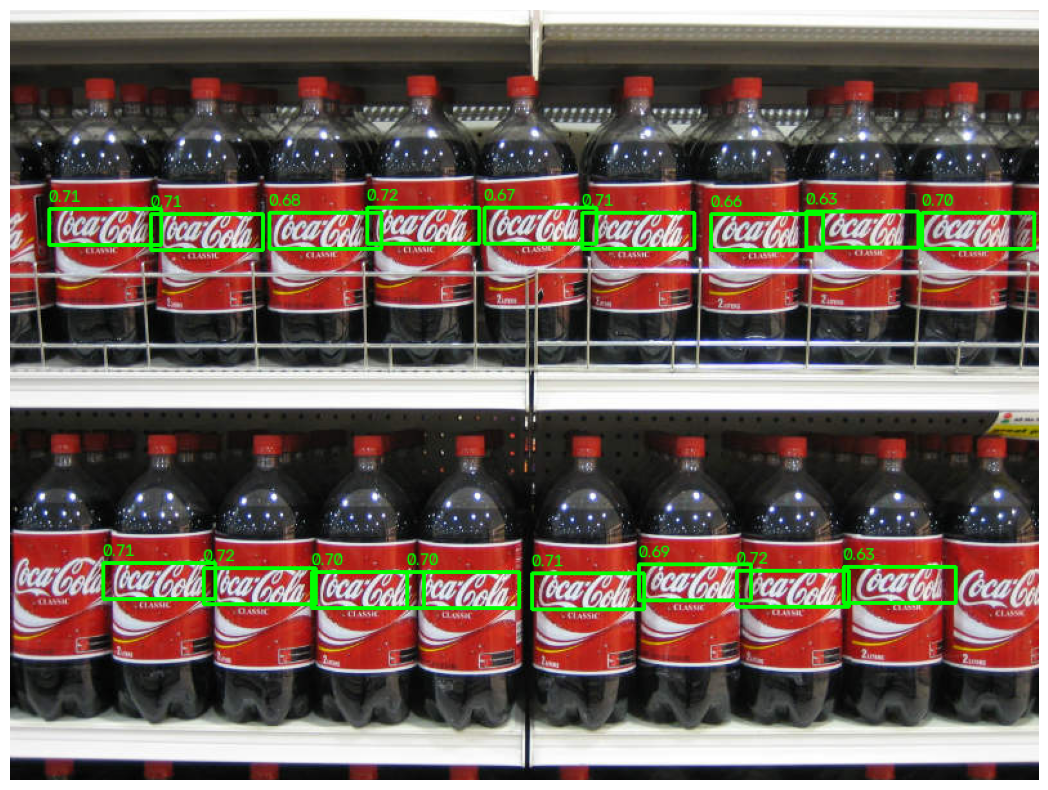

In [26]:
output = img.copy()

for detection in detections:

    x1 = detection["x1"]
    y1 = detection["y1"]
    x2 = detection["x2"]
    y2 = detection["y2"]

    score = detection["score"]

    cv.rectangle(
        output,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv.putText(
        output,
        f"{score:.2f}",
        (x1, max(15, y1 - 5)),
        cv.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 255, 0),
        1,
        cv.LINE_AA
    )


plt.figure(
    figsize=(15, 10)
)

plt.imshow(
    cv.cvtColor(
        output,
        cv.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

### 3- Generalizar el algoritmo del item 2 para todas las imágenes.

In [27]:
def detect_general(
    img,
    template,
    scales,
    threshold=0.62,
    iou_threshold=0.20,
    delta=0.04
):

    results = evaluate_scales(
        img,
        template,
        scales
    )

    scale_results = []

    for result in results:

        detections = get_detections(
            result["score_map"],
            result["w"],
            result["h"],
            threshold,
            iou_threshold
        )

        if len(detections) > 0:

            mean_score = np.mean([
                detection["score"]
                for detection in detections
            ])

            scale_results.append({
                "scale": result["scale"],
                "detections": detections,
                "mean_score": mean_score
            })

    # Si alguna escala supera el threshold
    if len(scale_results) > 0:

        best = max(
            scale_results,
            key=lambda x: (
                x["mean_score"],
                len(x["detections"])
            )
        )

        return (
            best["detections"],
            best["scale"]
        )

    # --------------------------------------
    # Fallback:
    # ninguna escala pasó el threshold
    # --------------------------------------

    best_score = max(
        result["max_score"]
        for result in results
    )

    candidates = [
        result
        for result in results
        if result["max_score"]
        >= best_score - delta
    ]

    best = max(
        candidates,
        key=lambda x: x["scale"]
    )

    x, y = best["max_loc"]

    detections = [{
        "x1": x,
        "y1": y,
        "x2": x + best["w"],
        "y2": y + best["h"],
        "score": best["max_score"]
    }]

    return (
        detections,
        best["scale"]
    )

logo_1.png - escala: 0.705 - detecciones: 1


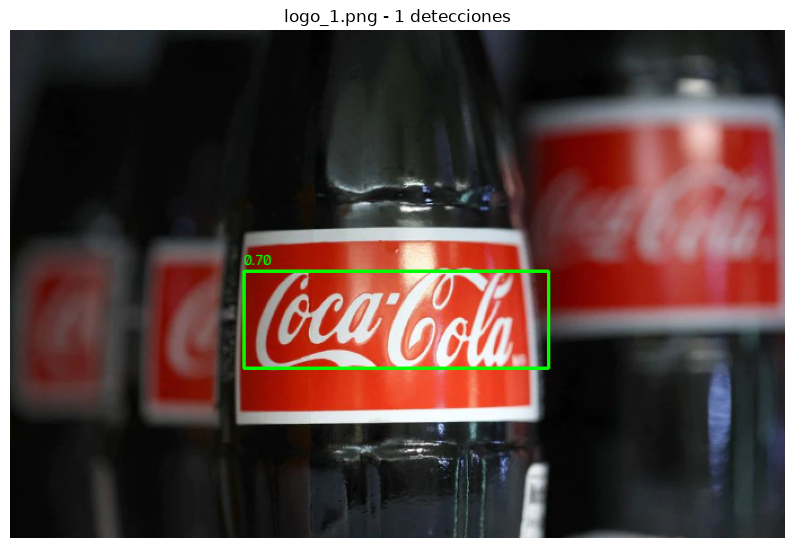

coca_logo_1.png - escala: 0.427 - detecciones: 1


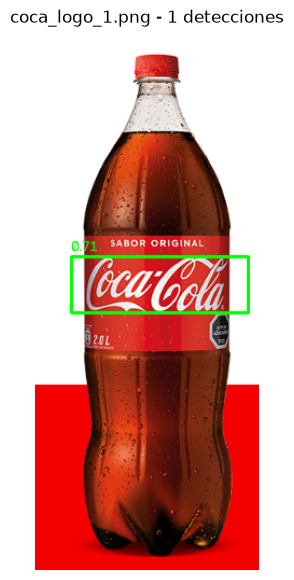

coca_logo_2.png - escala: 0.566 - detecciones: 1


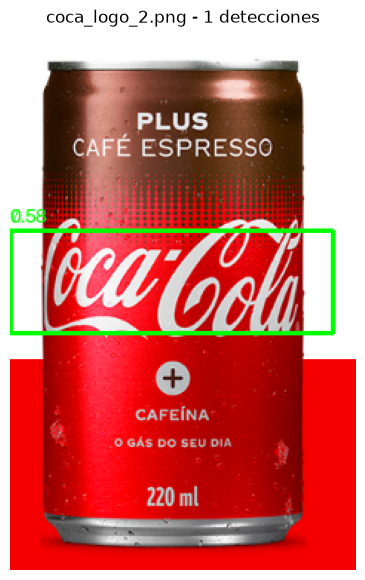

coca_multi.png - escala: 0.219 - detecciones: 17


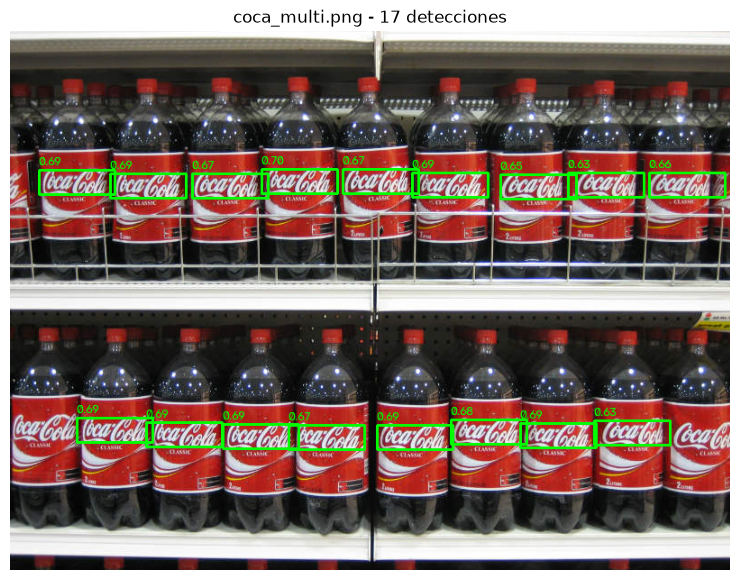

coca_retro_1.png - escala: 1.328 - detecciones: 1


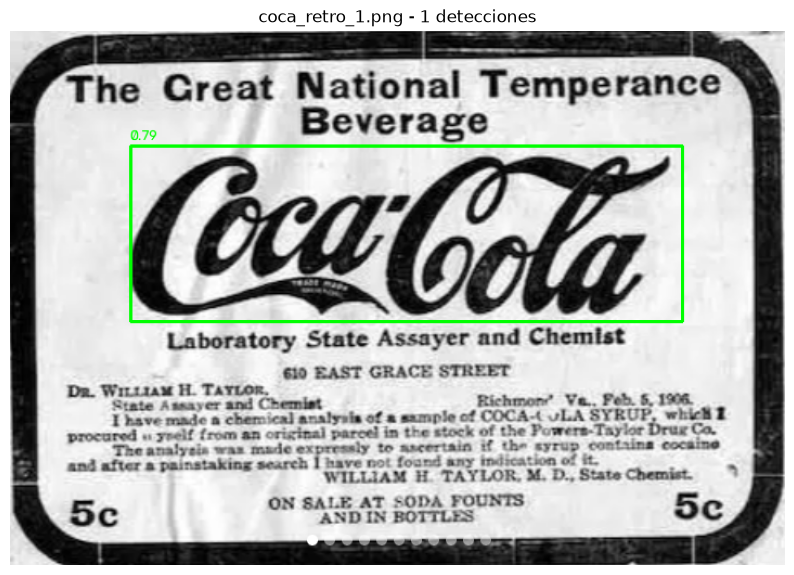

coca_retro_2.png - escala: 0.358 - detecciones: 1


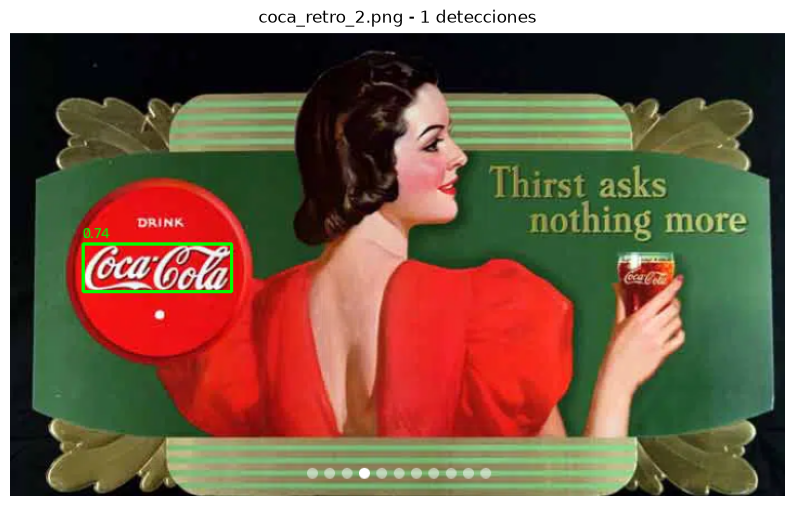

COCA-COLA-LOGO.jpg - escala: 3.131 - detecciones: 1


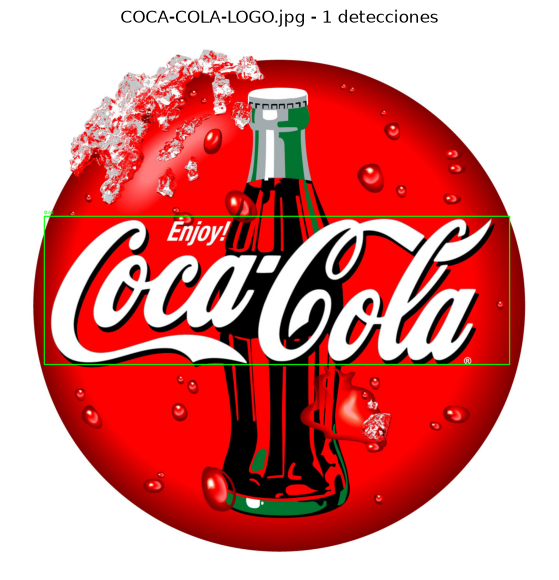

In [28]:
for image_name in file_list:

    img = cv.imread(image_path + image_name)

    if img is None:
        continue

    detections, scale = detect_general(
        img,
        template,
        scales
    )

    output = img.copy()

    for detection in detections:

        x1 = detection["x1"]
        y1 = detection["y1"]
        x2 = detection["x2"]
        y2 = detection["y2"]

        score = detection["score"]

        cv.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv.putText(
            output,
            f"{score:.2f}",
            (x1, max(15, y1 - 5)),
            cv.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            1,
            cv.LINE_AA
        )

    print(
        image_name,
        "- escala:",
        round(scale, 3),
        "- detecciones:",
        len(detections)
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.imshow(
        cv.cvtColor(
            output,
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"{image_name} - "
        f"{len(detections)} detecciones"
    )

    plt.axis("off")
    plt.show()